In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
import healpy as hp

Observable: [ True]
target name ever observable always observable fraction of time observable
----------- --------------- ----------------- ---------------------------
         M1            True             False         0.22916666666666666


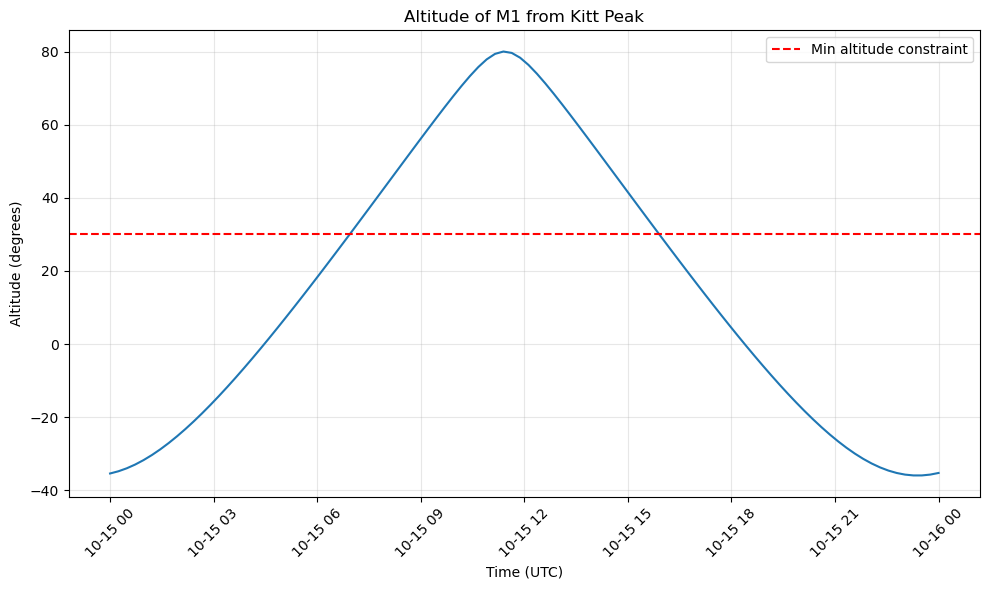

In [2]:
import astropy.units as u
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
from astroplan import Observer, FixedTarget
import numpy as np
import matplotlib.pyplot as plt

# Define your observing site
site = EarthLocation(lat=31.9634*u.deg, lon=-111.5992*u.deg, height=2096*u.m)  # Kitt Peak
observer = Observer(location=site, name="Kitt Peak", timezone="US/Arizona")

# Define your target
target_coord = SkyCoord(ra=83.6331*u.deg, dec=22.0145*u.deg, frame='icrs')  # M1 (Crab Nebula)
target = FixedTarget(coord=target_coord, name="M1")

# Define observation time range
start_time = Time('2025-10-15 00:00:00')
end_time = Time('2025-10-16 00:00:00')
time_range = Time([start_time, end_time])

# Check if target is observable during night
from astroplan import (AltitudeConstraint, AtNightConstraint, 
                       is_observable, observability_table)

# Define constraints
constraints = [
    AltitudeConstraint(min=30*u.deg),  # Above 30° altitude
    AtNightConstraint.twilight_astronomical()  # During astronomical night
]

# Check observability
observable = is_observable(constraints, observer, target, time_range=time_range)
print(f"Observable: {observable}")

# Get detailed observability table
obs_table = observability_table(constraints, observer, [target], 
                                 time_range=time_range)
print(obs_table)

# Calculate altitude over time for plotting
times = start_time + np.linspace(0, 24, 100)*u.hour
altaz_frame = AltAz(obstime=times, location=site)
target_altaz = target_coord.transform_to(altaz_frame)

# Plot altitude vs time
plt.figure(figsize=(10, 6))
plt.plot(times.datetime, target_altaz.alt.deg)
plt.axhline(y=30, color='r', linestyle='--', label='Min altitude constraint')
plt.xlabel('Time (UTC)')
plt.ylabel('Altitude (degrees)')
plt.title(f'Altitude of {target.name} from {observer.name}')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

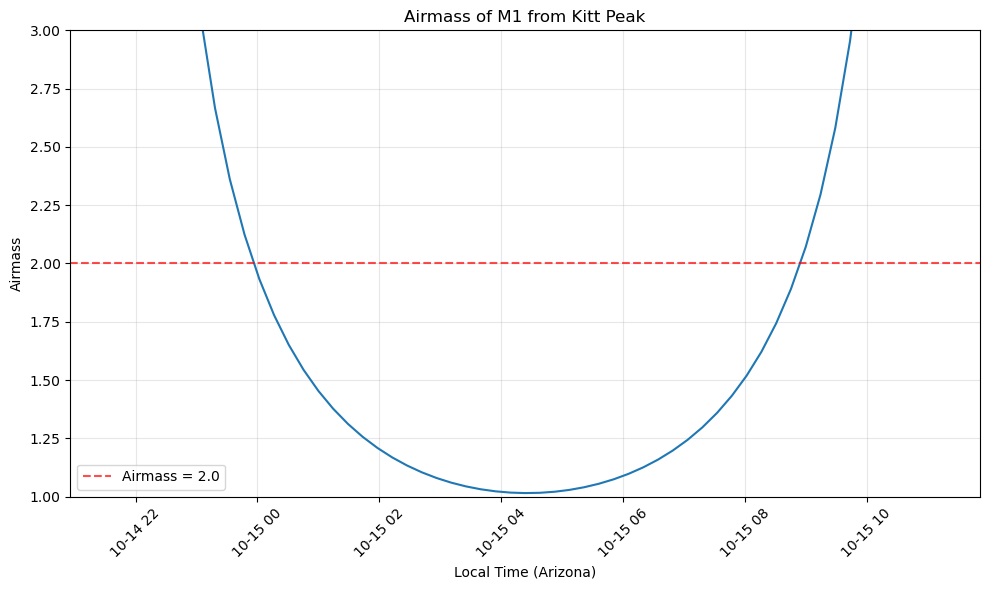

In [4]:
import astropy.units as u
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
from astroplan import Observer, FixedTarget
import numpy as np
import matplotlib.pyplot as plt

# Define your observing site
site = EarthLocation(lat=31.9634*u.deg, lon=-111.5992*u.deg, height=2096*u.m)  # Kitt Peak
observer = Observer(location=site, name="Kitt Peak", timezone="US/Arizona")

# Define your target
target_coord = SkyCoord(ra=83.6331*u.deg, dec=22.0145*u.deg, frame='icrs')  # M1 (Crab Nebula)
target = FixedTarget(coord=target_coord, name="M1")

# Define observation time range
start_time = Time('2025-10-15 00:00:00')
times = start_time + np.linspace(0, 24, 100)*u.hour

# Calculate altitude and airmass
altaz_frame = AltAz(obstime=times, location=site)
target_altaz = target_coord.transform_to(altaz_frame)

# Calculate airmass (sec(z) approximation, undefined below horizon)
airmass = target_altaz.secz
airmass[target_altaz.alt.deg < 0] = np.nan  # Set below-horizon to NaN

# Convert to local time
local_times = [observer.astropy_time_to_datetime(t) for t in times]

# Plot airmass vs local time
plt.figure(figsize=(10, 6))
plt.plot(local_times, airmass)
plt.axhline(y=2.0, color='r', linestyle='--', label='Airmass = 2.0', alpha=0.7)
plt.xlabel('Local Time (Arizona)')
plt.ylabel('Airmass')
plt.title(f'Airmass of {target.name} from {observer.name}')
plt.grid(True, alpha=0.3)
plt.gca().invert_yaxis()  # Lower airmass at top
plt.xticks(rotation=45)
plt.legend()
plt.ylim(1, 3)  # Typical observable range
plt.tight_layout()
plt.show()

## XMM

In [16]:
import astropy.units as u
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, get_moon, get_sun
from astropy.time import Time
from astroplan import Observer, FixedTarget
import numpy as np
from datetime import datetime, timedelta

# Define your observing site
site = EarthLocation(lat=31.9634*u.deg, lon=-111.5992*u.deg, height=2096*u.m)
observer = Observer(location=site, name="Kitt Peak", timezone="US/Arizona")

# Define your target
target_coord = SkyCoord(ra=35.5*u.deg, dec=-5*u.deg, frame='icrs')
target = FixedTarget(coord=target_coord, name="M1")

# Year to analyze
start_date = Time(f'2025-07-01 00:00:00')
end_date = Time(f'2026-06-30 23:59:59')

# Iterate through each night
good_nights = []
current_date = start_date

while current_date < end_date:
    # Get sunset and sunrise for the night
    sunset = observer.sun_set_time(current_date, which='next')
    sunrise = observer.sun_rise_time(sunset, which='next')
    
    # Sample the night at 5-minute intervals
    night_times = sunset + np.linspace(0, (sunrise - sunset).to(u.hour).value, 
                                        int((sunrise - sunset).to(u.hour).value * 12)) * u.hour
    
    # Calculate sun altitude to apply 15° twilight constraint
    altaz_frame = AltAz(obstime=night_times, location=site)
    sun_coords = get_sun(night_times)
    sun_altaz = sun_coords.transform_to(altaz_frame)
    
    # Calculate target airmass throughout the night
    target_altaz = target_coord.transform_to(altaz_frame)
    airmass = target_altaz.secz
    
    # Calculate moon altitude throughout the night
    moon_coords = get_moon(night_times)
    moon_altaz = moon_coords.transform_to(altaz_frame)
    
    # Count time with all conditions met:
    # - Sun below -15° (15° twilight)
    # - Target airmass < 1.5 and above horizon
    # - Moon below horizon
    good_conditions_mask = (sun_altaz.alt.deg < -15) & \
                          (airmass < 1.5) & (target_altaz.alt.deg > 0) & \
                          (moon_altaz.alt.deg < 0)
    n_good_samples = np.sum(good_conditions_mask)
    
    # Convert to hours (5-minute sampling)
    hours_observable = n_good_samples * 5.0 / 60.0
    
    if hours_observable >= 2.0:
        good_airmass_values = airmass[good_conditions_mask]
        # Convert sunset to local time to get correct local date
        local_sunset = observer.astropy_time_to_datetime(sunset)
        good_nights.append({
            'night': local_sunset.date(),
            'sunset': local_sunset,
            'sunrise': observer.astropy_time_to_datetime(sunrise),
            'hours_observable': hours_observable,
            'min_airmass': np.nanmin(good_airmass_values) if n_good_samples > 0 else np.nan,
            'avg_airmass': np.nanmean(good_airmass_values) if n_good_samples > 0 else np.nan
        })
    
    # Move to next day
    current_date = current_date + 1*u.day

# Print results
print(f"\nNights with ≥2 hours at airmass < 1.5 (15° twilight, moon down) for {target.name}:")
print(f"Total: {len(good_nights)} nights\n")
print(f"{'Night':<12} {'Hours':<8} {'Min AM':<8} {'Avg AM':<8}")
print("-" * 40)

for night in good_nights:
    print(f"{night['night']} {night['hours_observable']:>6.1f}h  {night['min_airmass']:>6.2f}  {night['avg_airmass']:>6.2f}")

# Print summary statistics
if good_nights:
    hours = [n['hours_observable'] for n in good_nights]
    avg_airmasses = [n['avg_airmass'] for n in good_nights]
    print(f"\nSummary:")
    print(f"  Best night: {max(hours):.1f} hours")
    print(f"  Average hours: {np.mean(hours):.1f} hours")
    print(f"  Average airmass: {np.mean(avg_airmasses):.2f}")
    print(f"  Observing season: {good_nights[0]['night']} to {good_nights[-1]['night']}")
else:
    print("\nNo nights meet all criteria.")

        Use get_body("moon") instead. [warnings]



Nights with ≥2 hours at airmass < 1.5 (15° twilight, moon down) for M1:
Total: 89 nights

Night        Hours    Min AM   Avg AM  
----------------------------------------
2025-08-21    2.2h    1.25    1.33
2025-08-22    2.2h    1.25    1.33
2025-08-23    2.3h    1.25    1.32
2025-08-24    2.4h    1.25    1.32
2025-08-25    2.5h    1.25    1.32
2025-08-26    2.5h    1.25    1.31
2025-08-27    2.6h    1.25    1.31
2025-08-28    2.7h    1.25    1.31
2025-08-29    2.8h    1.25    1.31
2025-08-30    2.8h    1.25    1.31
2025-08-31    2.9h    1.25    1.31
2025-09-01    3.0h    1.25    1.31
2025-09-02    3.1h    1.25    1.31
2025-09-03    2.3h    1.25    1.27
2025-09-17    2.2h    1.25    1.32
2025-09-18    3.4h    1.25    1.31
2025-09-19    4.2h    1.25    1.33
2025-09-20    4.3h    1.25    1.33
2025-09-21    4.3h    1.25    1.33
2025-09-22    4.3h    1.25    1.33
2025-09-23    4.3h    1.25    1.33
2025-09-24    4.2h    1.25    1.33
2025-09-25    4.3h    1.25    1.33
2025-09-26    4.2h    1

## COSMOS

In [17]:
import astropy.units as u
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, get_moon, get_sun
from astropy.time import Time
from astroplan import Observer, FixedTarget
import numpy as np
from datetime import datetime, timedelta

# Define your observing site
site = EarthLocation(lat=31.9634*u.deg, lon=-111.5992*u.deg, height=2096*u.m)
observer = Observer(location=site, name="Kitt Peak", timezone="US/Arizona")

# Define your target
target_coord = SkyCoord(ra=150*u.deg, dec=2.5*u.deg, frame='icrs')
target = FixedTarget(coord=target_coord, name="M1")

# Year to analyze
start_date = Time(f'2025-07-01 00:00:00')
end_date = Time(f'2026-06-30 23:59:59')

# Iterate through each night
good_nights = []
current_date = start_date

while current_date < end_date:
    # Get sunset and sunrise for the night
    sunset = observer.sun_set_time(current_date, which='next')
    sunrise = observer.sun_rise_time(sunset, which='next')
    
    # Sample the night at 5-minute intervals
    night_times = sunset + np.linspace(0, (sunrise - sunset).to(u.hour).value, 
                                        int((sunrise - sunset).to(u.hour).value * 12)) * u.hour
    
    # Calculate sun altitude to apply 15° twilight constraint
    altaz_frame = AltAz(obstime=night_times, location=site)
    sun_coords = get_sun(night_times)
    sun_altaz = sun_coords.transform_to(altaz_frame)
    
    # Calculate target airmass throughout the night
    target_altaz = target_coord.transform_to(altaz_frame)
    airmass = target_altaz.secz
    
    # Calculate moon altitude throughout the night
    moon_coords = get_moon(night_times)
    moon_altaz = moon_coords.transform_to(altaz_frame)
    
    # Count time with all conditions met:
    # - Sun below -15° (15° twilight)
    # - Target airmass < 1.5 and above horizon
    # - Moon below horizon
    good_conditions_mask = (sun_altaz.alt.deg < -15) & \
                          (airmass < 1.5) & (target_altaz.alt.deg > 0) & \
                          (moon_altaz.alt.deg < 0)
    n_good_samples = np.sum(good_conditions_mask)
    
    # Convert to hours (5-minute sampling)
    hours_observable = n_good_samples * 5.0 / 60.0
    
    if hours_observable >= 2.0:
        good_airmass_values = airmass[good_conditions_mask]
        # Convert sunset to local time to get correct local date
        local_sunset = observer.astropy_time_to_datetime(sunset)
        good_nights.append({
            'night': local_sunset.date(),
            'sunset': local_sunset,
            'sunrise': observer.astropy_time_to_datetime(sunrise),
            'hours_observable': hours_observable,
            'min_airmass': np.nanmin(good_airmass_values) if n_good_samples > 0 else np.nan,
            'avg_airmass': np.nanmean(good_airmass_values) if n_good_samples > 0 else np.nan
        })
    
    # Move to next day
    current_date = current_date + 1*u.day

# Print results
print(f"\nNights with ≥2 hours at airmass < 1.5 (15° twilight, moon down) for {target.name}:")
print(f"Total: {len(good_nights)} nights\n")
print(f"{'Night':<12} {'Hours':<8} {'Min AM':<8} {'Avg AM':<8}")
print("-" * 40)

for night in good_nights:
    print(f"{night['night']} {night['hours_observable']:>6.1f}h  {night['min_airmass']:>6.2f}  {night['avg_airmass']:>6.2f}")

# Print summary statistics
if good_nights:
    hours = [n['hours_observable'] for n in good_nights]
    avg_airmasses = [n['avg_airmass'] for n in good_nights]
    print(f"\nSummary:")
    print(f"  Best night: {max(hours):.1f} hours")
    print(f"  Average hours: {np.mean(hours):.1f} hours")
    print(f"  Average airmass: {np.mean(avg_airmasses):.2f}")
    print(f"  Observing season: {good_nights[0]['night']} to {good_nights[-1]['night']}")
else:
    print("\nNo nights meet all criteria.")

        Use get_body("moon") instead. [warnings]



Nights with ≥2 hours at airmass < 1.5 (15° twilight, moon down) for M1:
Total: 89 nights

Night        Hours    Min AM   Avg AM  
----------------------------------------
2025-11-18    2.0h    1.17    1.30
2025-11-19    2.1h    1.17    1.29
2025-11-20    2.2h    1.16    1.29
2025-11-21    2.2h    1.16    1.28
2025-11-22    2.2h    1.16    1.27
2025-11-23    2.3h    1.15    1.27
2025-11-24    2.4h    1.15    1.26
2025-11-25    2.5h    1.15    1.26
2025-11-26    2.6h    1.15    1.26
2025-11-27    2.7h    1.15    1.25
2025-11-28    2.7h    1.15    1.26
2025-11-29    2.8h    1.15    1.25
2025-11-30    2.7h    1.15    1.24
2025-12-15    2.4h    1.15    1.27
2025-12-16    3.5h    1.15    1.23
2025-12-17    4.2h    1.15    1.23
2025-12-18    4.2h    1.15    1.23
2025-12-19    4.3h    1.15    1.23
2025-12-20    4.3h    1.15    1.23
2025-12-21    4.4h    1.15    1.23
2025-12-22    4.5h    1.15    1.23
2025-12-23    4.6h    1.15    1.23
2025-12-24    4.7h    1.15    1.23
2025-12-25    4.8h    1